# EDA World Map with Geometry

In [63]:
import os, sys
from datetime import datetime, timedelta
from collections import Counter

import numpy as np
import pandas as pd
from typing import List
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler, normalize
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout

from shapely import wkt

data_path = "../kgdata/edges_v3.tsv"
tmp_dir = "../tmp/"
output_dir = "../output/"

if not os.path.isdir(tmp_dir):
    os.mkdir(tmp_dir)

if not os.path.isdir(output_dir):
    os.mkdir(output_dir)

graph_cache = tmp_dir + "wikidata.sqlite3"

df = pd.read_csv(data_path, sep='\t')

In [2]:
print(df["label"].unique())

['type' 'EventId' 'DescriptionText' 'EventType' 'StartTime' 'EndTime'
 'StartDistanceFromPort_km' 'StartDistanceFromShore_km'
 'EndDistanceFromPort_km' 'EndDistanceFromShore_km' 'Location'
 'EventGeometry' 'HasParticipant' 'ValidatedBy' 'ExplainedBy'
 'HasProvenance' 'BehaviorType' 'UncertaintyNote' 'AvgSpeed_knots'
 'PatternGeometry' 'UnexplainedByWeatherOrPort' 'ObservationId' 'MMSI'
 'Lat' 'Lon' 'Speed' 'Course' 'Timestamp' 'DistanceFromPortKM'
 'DistanceFromShoreKM' 'Source' 'SSVID' 'VesselName' 'CallSign' 'Flag'
 'VesselTypeId' 'GroupType' 'HasMember' 'AsWKT' 'CentroidLat'
 'CentroidLon' 'CRS' 'PortName' 'BerthGeometry' 'TypeCode' 'TypeName'
 'subClassOf' 'FishingEffortScore' 'GearType' 'ZoneCode' 'ZoneName'
 'ZoneType' 'ZoneGeometry' 'SourceID' 'SourceName' 'SourceType'
 'SourceURL' 'MemberVessel' 'MembershipRole' 'MemberOf' 'PatternTypeID'
 'PatternTypeName' 'domain' 'range' ' type']


In [3]:
df[df["node1"] == "VesselIdentity_0"]

,node1,label,node2,edge_id
319703,VesselIdentity_0,type,VesselIdentity,VI_0
319704,VesselIdentity_0,MMSI,210316168866209,VI_1
319705,VesselIdentity_0,SSVID,412478603,VI_2
319706,VesselIdentity_0,VesselName,YUE ZHU YU YUN40019,VI_3
319707,VesselIdentity_0,CallSign,40019,VI_4
319708,VesselIdentity_0,Flag,CHN,VI_5
319709,VesselIdentity_0,VesselTypeId,VesselType_5,VI_6


In [4]:
df[(df["node1"] == "VesselType_0") & (df["label"] == "TypeName")].node2.values[0]

'BunkerVessel'

In [5]:
df[df["label"] == "HasParticipant"].node1.unique()

array(['LoiteringEvent_0', 'LoiteringEvent_1', 'LoiteringEvent_2', ...,
       'FishingEvent_328', 'FishingEvent_329', 'FishingEvent_330'],
      shape=(1698,), dtype=object)

In [6]:
geometries = df[df["label"] == "AsWKT"].node1.values
aswkt = df[df["label"] == "AsWKT"].node2.values
aswkt[0]

def extract_polygon(geometry: str):
    aswkt = df[(df["node1"] == geometry)
               & (df["label"] == "AsWKT")].node2.values[0]
    return aswkt

In [7]:
aswkt = extract_polygon("Geometry_0")

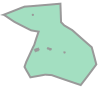

In [8]:
geom = wkt.loads(aswkt)
geom

In [9]:
def polygon_plot(geometry: str):
    fix, ax = plt.subplots(figsize=(10, 6))

    aswkt = extract_polygon(geometry)
    geom = wkt.loads(aswkt)
    
    world_map = Basemap(projection="mill",
                        lon_0=0, resolution='i', ax=ax)
    world_map.drawcoastlines()
    world_map.drawmapboundary(fill_color="lightblue")
    world_map.fillcontinents(color="lightgray", lake_color="lightblue")

    for polygon in geom.geoms:
        coords = list(polygon.exterior.coords)
        lons = [c[0] for c in coords]
        lats = [c[1] for c in coords]
        x, y = world_map(lons, lats)
        ax.fill(x, y, color="red", alpha=0.2)
        
    plt.show()

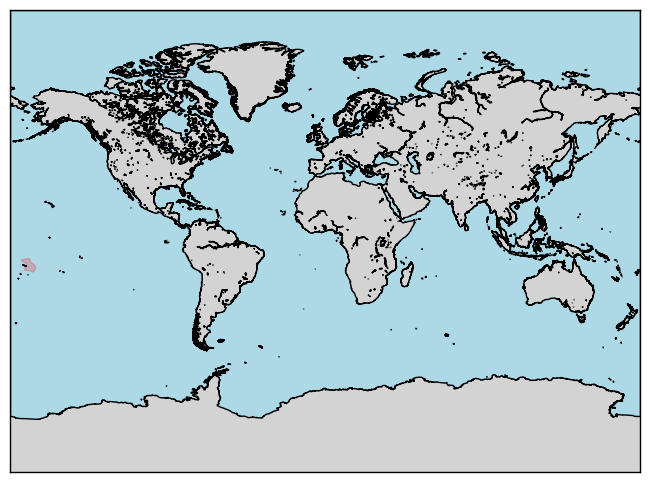

In [10]:
polygon_plot("Geometry_0")

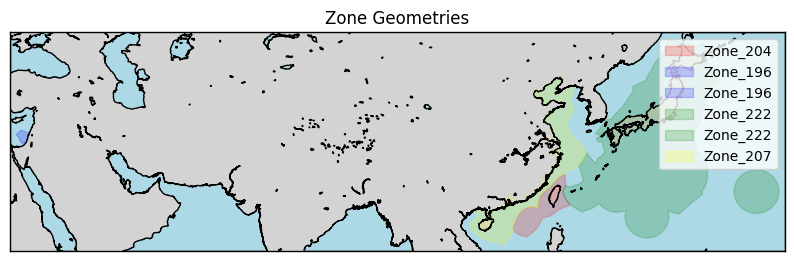

In [11]:
ZONES = ["Zone_204", "Zone_196", "Zone_222", "Zone_207"]
GEOMETRIES = ["Geometry_" + df[(df["node1"] == zone) & (df["label"] == "ZoneGeometry")].node2.values[0].split('_')[1] \
              for zone in ZONES]
ZONE_COLOR = ["red", "blue", "green", "yellow"]

def all_geom_plot(geometries: List):
    fix, ax = plt.subplots(figsize=(10, 6))

    all_lons, all_lats = [], []
    geoms = []

    for geometry in geometries:
        aswkt = extract_polygon(geometry)
        geom = wkt.loads(aswkt)
        geoms.append(geom)

        for polygon in geom.geoms:
            coords = list(polygon.exterior.coords)
            all_lons += [c[0] for c in coords]
            all_lats += [c[1] for c in coords]

    pad = 1.0
    lat_min, lat_max = min(all_lats) - pad, max(all_lats) + pad
    lon_min, lon_max = min(all_lons) - pad, max(all_lons) + pad

    world_map = Basemap(projection="mill",
                        lon_0=0,
                        llcrnrlat=lat_min, urcrnrlat=lat_max,
                        llcrnrlon=lon_min, urcrnrlon=lon_max,
                        resolution='i', ax=ax)
    world_map.drawcoastlines()
    world_map.drawmapboundary(fill_color="lightblue")
    world_map.fillcontinents(color="lightgray", lake_color="lightblue")
    
    for idx, geom in enumerate(geoms):
        for polygon in geom.geoms:
            coords = list(polygon.exterior.coords)
            lons = [c[0] for c in coords]
            lats = [c[1] for c in coords]
            x, y = world_map(lons, lats)
            ax.fill(x, y, color=ZONE_COLOR[idx], alpha=0.2, label=ZONES[idx])
            
    ax.legend(loc="upper right")
    plt.title("Zone Geometries")
    plt.show()

all_geom_plot(GEOMETRIES)

In [12]:
zonenames = df[df["label"] == "ZoneName"].node2.values
for zonename in zonenames:
    if "philippine" in zonename.lower():
        print(zonename)

Philippine Exclusive Economic Zone


In [13]:
df[(df["label"] == "ZoneName") & (df["node2"] == "Philippine Exclusive Economic Zone")]

,node1,label,node2,edge_id
357605,Zone_169,ZoneName,Philippine Exclusive Economic Zone,Zone847


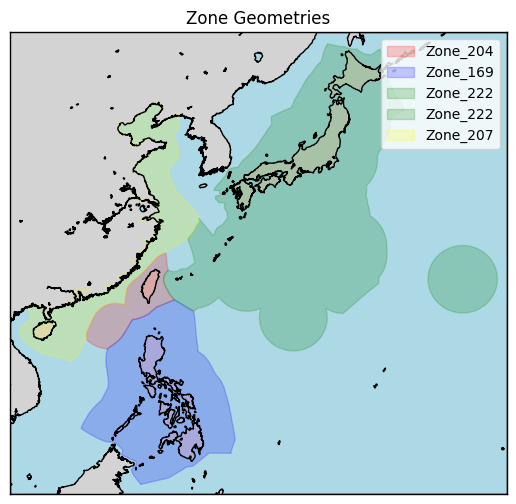

In [14]:
ZONES = ["Zone_204", "Zone_169", "Zone_222", "Zone_207"]
GEOMETRIES = ["Geometry_" + df[(df["node1"] == zone) & (df["label"] == "ZoneGeometry")].node2.values[0].split('_')[1] \
              for zone in ZONES]
ZONE_COLOR = ["red", "blue", "green", "yellow"]

all_geom_plot(GEOMETRIES)

In [15]:
ZONES = ["Zone_204", "Zone_169", "Zone_222", "Zone_207"]
GEOMETRIES = ["Geometry_" + df[(df["node1"] == zone) & (df["label"] == "ZoneGeometry")].node2.values[0].split('_')[1] \
              for zone in ZONES]
ZONE_COLOR = ["red", "blue", "green", "yellow"]
COLOR_MAP = {GEOMETRIES[i]:ZONE_COLOR[i] for i in range(len(ZONES))}

vessels = df[(df["label"] == "type") & (df["node2"] == "VesselIdentity")].node1.values

vessel2flag = {}

for vessel in vessels:
    vessel2flag[vessel] = df[(df["node1"] == vessel) &
                             (df["label"] == "Flag")].node2.values[0]

def vessel2type(vessel: str):
    vt = df[(df["node1"] == vessel) &
            (df["label"] == "VesselTypeId")].node2.values[0]
    return df[(df["node1"] == vt) & (df["label"] == "TypeName")].node2.values[0]

def vessel2event(vessel: str):
    return df[(df["label"] == "HasParticipant") &
              (df["node2"] == vessel)].node1.to_list()

def event2latlon(event: str):
    e_type = df[(df["node1"] == event) & (df["label"] == "EventType")].node2.values[0]
    zone = df[(df["node1"] == event) & (df["label"] == "Location")].node2.values[0]
    geometry = df[(df["node1"] == event) & (df["label"] == "EventGeometry")].node2.values[0]
    e_lat = float(df[(df["node1"] == geometry) & (df["label"] == "CentroidLat")].node2.values[0])
    e_lon = float(df[(df["node1"] == geometry) & (df["label"] == "CentroidLon")].node2.values[0])
    
    return (e_type, zone, e_lat, e_lon)

event_mmap = {
    "loitering": "o",
    "port_visit": "s",
    "fishing": "^"
}

zone_cmap = {
    "Zone_204": "red",
    "Zone_196": "blue",
    "Zone_222": "green",
    "Zone_207": "yellow"
}

def vessel_event_plot_with_geometry(vessel: str):
    events = vessel2event(vessel)
    events_info = list(map(lambda x: event2latlon(x), events))

    types = np.array([x[0] for x in events_info])
    zones = np.array([x[1] for x in events_info])
    lats = np.array([x[2] for x in events_info])
    lons = np.array([x[3] for x in events_info])

    lat_min, lat_max = lats.min() - 0.01, lats.max() + 0.01
    lon_min, lon_max = lons.min() - 0.01, lons.max() + 0.01

    fix, ax = plt.subplots(figsize=(10, 6))
    world_map = Basemap(projection="mill",
                        lon_0=0,
                        llcrnrlat=lat_min,
                        urcrnrlat=lat_max,
                        llcrnrlon=lon_min,
                        urcrnrlon=lon_max,
                        resolution='i',
                        ax=ax)
    world_map.drawcoastlines()
    world_map.drawmapboundary(fill_color="lightblue")
    world_map.fillcontinents(color="lightgray", lake_color="lightblue")

    x, y = world_map(lons, lats)

    title = f"{vessel2type(vessel)}:{vessel2flag[vessel]}"

    for event, marker in event_mmap.items():
        for zone, color in zone_cmap.items():
            idx = (types == event) & (zones == zone)
            world_map.scatter(
                x[idx], y[idx], marker=marker,
                color=color, s=50, edgecolors="black",
                label=f"{event}-{zone}"
            )

    for idx, geometry in enumerate(GEOMETRIES):
        aswkt = extract_polygon(geometry)
        geom = wkt.loads(aswkt)

        for polygon in geom.geoms:
            coords = list(polygon.exterior.coords)
            lons = [c[0] for c in coords]
            lats = [c[1] for c in coords]
            x, y = world_map(lons, lats)
            ax.fill(x, y, color=ZONE_COLOR[idx], alpha=0.2)

    plt.title(title)
    plt.show()

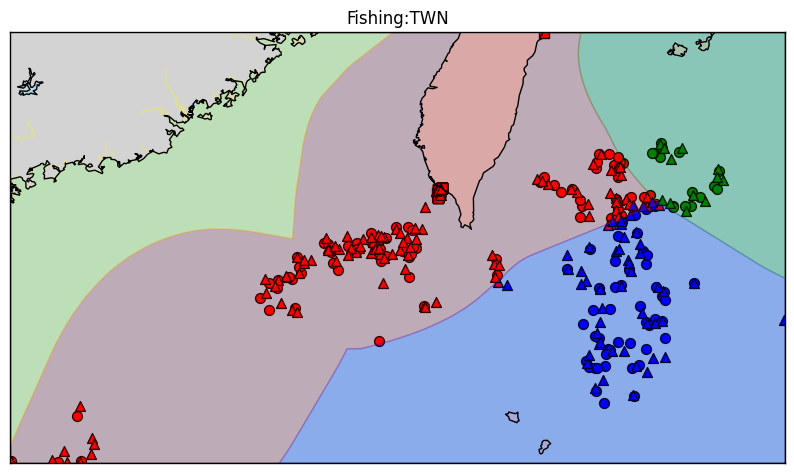

In [16]:
vessel_event_plot_with_geometry(vessels[6])

## Vessel Event Feature Engineering

In [50]:
def vessel_info(vessel: str):
    vdf = df[df["node1"] == vessel]

    vflag = vdf[vdf["label"] == "Flag"].node2.values[0]
    vtype_id = vdf[vdf["label"] == "VesselTypeId"].node2.values[0]
    vtype = df[(df["node1"] == vtype_id) & (df["label"] == "TypeName")].node2.values[0]

    return vflag, vtype

In [52]:
y = [vessel_info(vessel) for vessel in vessels]
Counter(y)

Counter({('TWN', 'Fishing'): 6,
         ('CHN', 'Other'): 2,
         ('CHN', 'Passenger'): 2,
         (nan, 'Other'): 2,
         ('CHN', 'Cargo'): 1,
         ('TWN', 'Passenger'): 1,
         ('TWN', 'Other'): 1,
         (nan, 'Gear'): 1,
         ('CHN', 'Fishing'): 1})

In [119]:
def generate_feature(vessels: List, func):
    scaler = StandardScaler()
    return scaler.fit_transform(np.array(
        [func(vessel) for vessel in vessels]))

def clustering(X, n_clusters: int=2):
    kmeans = KMeans(n_clusters=n_clusters)
    return kmeans.fit_predict(X)

y = [vessel_info(vessel)[1] for vessel in vessels]

def metrics(X, y_pred):
    print()
    print(f"Silhouette Score: {silhouette_score(X, y_pred)}")
    print(f"Davies-Bouldin Score {davies_bouldin_score(X, y_pred)}")

def pca2d_plot(X, y, y_pred, k):
    if X.shape[1] != 2:
        if X.shape[1] < 2:
            return
        
        pca = PCA(n_components=2)
        X = pca.fit_transform(X)
    
    cmap = {yy: i for i, yy in enumerate(y)}
    labels = set(y)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for label in labels:
        mask = [yy == label for yy in y]
        axes[0].scatter(X[mask, 0], X[mask, 1], label=label, alpha=0.6)

    axes[0].set_title("Real Vessel Type")
    axes[0].legend(title="Vessel Type")

    axes[1].scatter(X[:, 0], X[:, 1], c=y_pred, alpha=0.6)
    axes[1].set_title(f"Clustering Vessel Type: {k}")
    plt.show()    

### Category 1: Event Frequency

In [115]:
EVENT_TYPES = ["PortVisitEvent", "LoiteringEvent", "FishingEvent"]

def vessel_event_feature_engineering_1(vessel: str) -> List:
    # Event Ratios(3), MeanEvent Duration(3), temporal behavior(3), spatial behavior(3)
    def count_event(vessel: str):
        counter = {event_type:0 for event_type in EVENT_TYPES}
        
        events = df[(df["label"] == "HasParticipant") &
                (df["node2"] == vessel)].node1.values
        events = list(map(lambda x: x.split('_')[0], events))
        for event in events:
            counter[event] += 1
        
        return counter

    counter = count_event(vessel)
    n_event = sum(counter.values())
    ratio = [counter[event_type] / n_event for event_type in EVENT_TYPES]

    return ratio


Silhouette Score: 0.772633274727883
Davies-Bouldin Score 0.5116286363218243


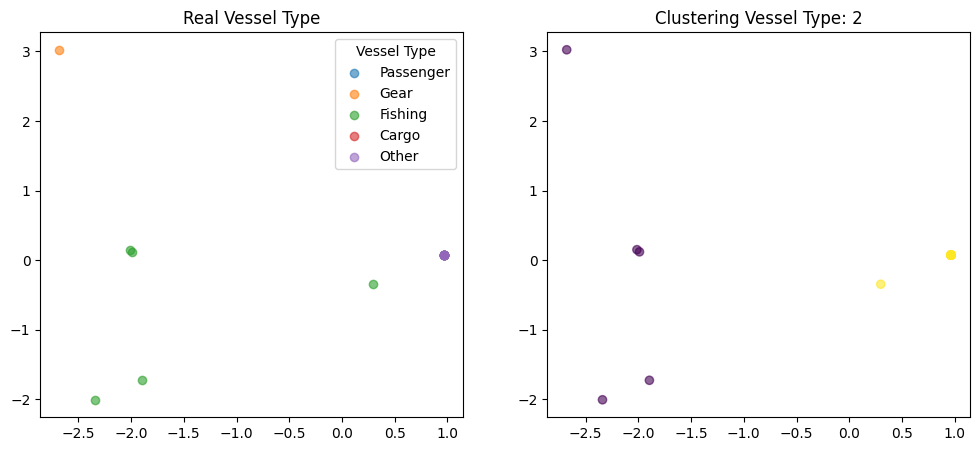

In [120]:
n_clusters=2
X = generate_feature(vessels, vessel_event_feature_engineering_1)
y_pred = clustering(X, n_clusters=n_clusters)

metrics(X, y_pred)
pca2d_plot(X, y, y_pred, n_clusters)


Silhouette Score: 0.8045772839384069
Davies-Bouldin Score 0.3295110039514219


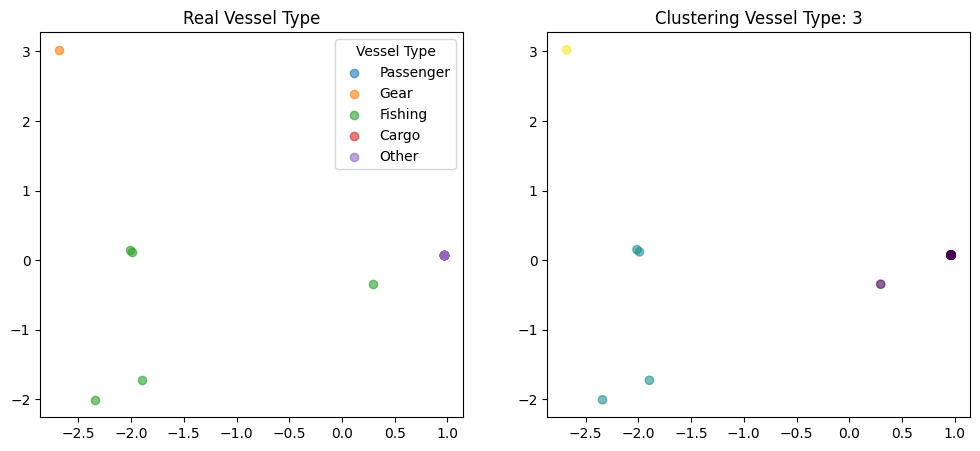

In [121]:
n_clusters=3
X = generate_feature(vessels, vessel_event_feature_engineering_1)
y_pred = clustering(X, n_clusters=n_clusters)

metrics(X, y_pred)
pca2d_plot(X, y, y_pred, n_clusters)


Silhouette Score: 0.8727235596715721
Davies-Bouldin Score 0.11056804390092707


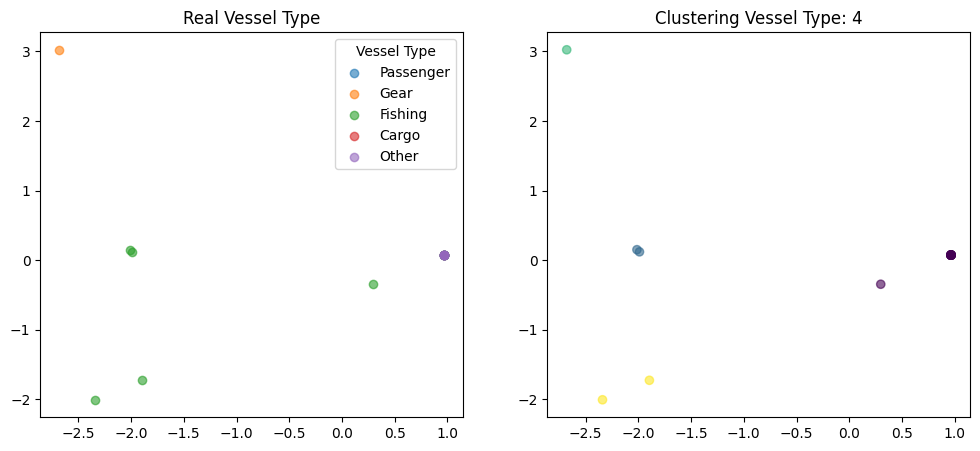

In [122]:
n_clusters=4
X = generate_feature(vessels, vessel_event_feature_engineering_1)
y_pred = clustering(X, n_clusters=n_clusters)

metrics(X, y_pred)
pca2d_plot(X, y, y_pred, n_clusters)


Silhouette Score: 0.8492187397920226
Davies-Bouldin Score 0.09987679412914599


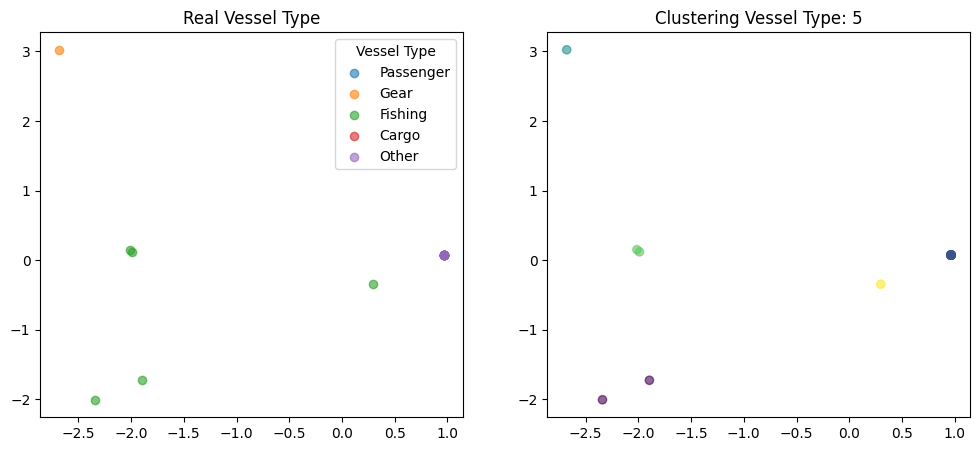

In [123]:
n_clusters=5
X = generate_feature(vessels, vessel_event_feature_engineering_1)
y_pred = clustering(X, n_clusters=n_clusters)

metrics(X, y_pred)
pca2d_plot(X, y, y_pred, n_clusters)

### Category 2: Zone based Behavior

In [109]:
EVENT_TYPES = ["PortVisitEvent", "LoiteringEvent", "FishingEvent"]
ZONES = ["Zone_204", "Zone_196", "Zone_222", "Zone_207"]
ZONE_CATEGORY = {zone:idx for idx, zone in enumerate(ZONES)}

def vessel_event_feature_engineering_2(vessel: str) -> List:
    # Event Ratios(3), MeanEvent Duration(3), temporal behavior(3), spatial behavior(3)
    def count_event(vessel: str):
        counter = {event_type:0 for event_type in EVENT_TYPES}
        
        events = df[(df["label"] == "HasParticipant") &
                    (df["node2"] == vessel)].node1.values
        events = list(map(lambda x: x.split('_')[0], events))
        for event in events:
            counter[event] += 1
        
        return counter

    def count_zone(vessel: str):
        counter = {zone:0 for zone in ZONES}
        events = df[(df["label"] == "HasParticipant") &
                    (df["node2"] == vessel)].node1.values

        for event in events:
            zone = df[(df["node1"] == event) &
                      (df["label"] == "Location")].node2.values[0]
            counter[zone] += 1

        return counter

    event_counter = count_event(vessel)
    zone_counter = count_zone(vessel)
    n_event = sum(event_counter.values())
    ratio = [event_counter[event_type] / n_event for event_type in EVENT_TYPES] \
        + [zone_counter[zone] / n_event for zone in ZONES]
    
    return ratio


Silhouette Score: 0.4395620937618217
Davies-Bouldin Score 0.7097440322003662


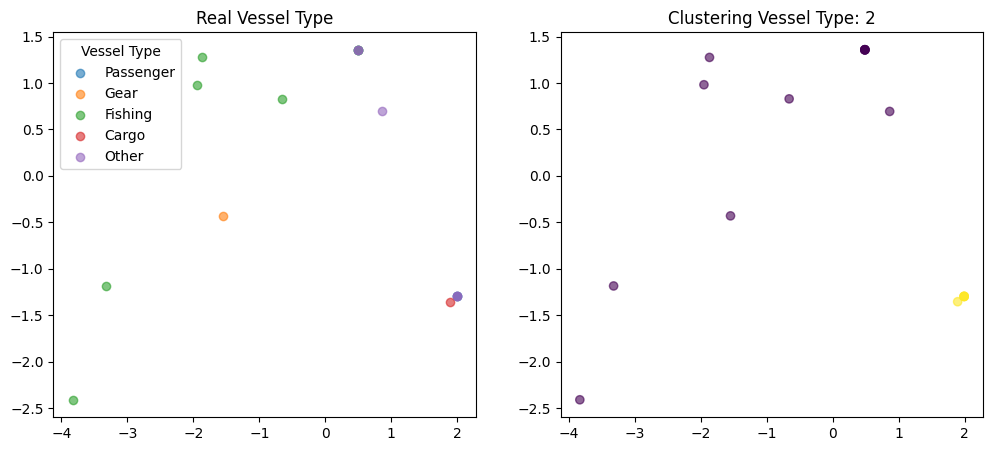

In [124]:
n_clusters=2
X = generate_feature(vessels, vessel_event_feature_engineering_2)
y_pred = clustering(X, n_clusters=n_clusters)

metrics(X, y_pred)
pca2d_plot(X, y, y_pred, n_clusters)


Silhouette Score: 0.553349957342445
Davies-Bouldin Score 0.9178551625019793


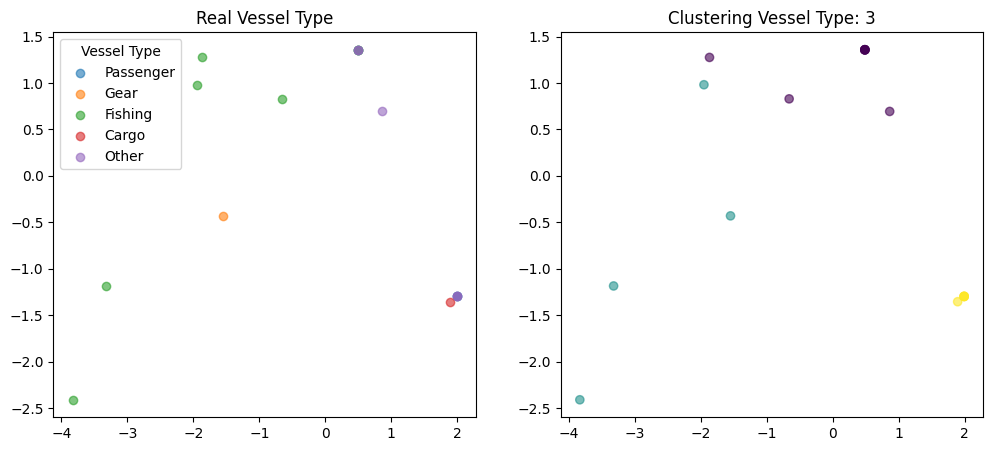

In [125]:
n_clusters=3
X = generate_feature(vessels, vessel_event_feature_engineering_2)
y_pred = clustering(X, n_clusters=n_clusters)

metrics(X, y_pred)
pca2d_plot(X, y, y_pred, n_clusters)


Silhouette Score: 0.6027475490689146
Davies-Bouldin Score 0.4710458615925569


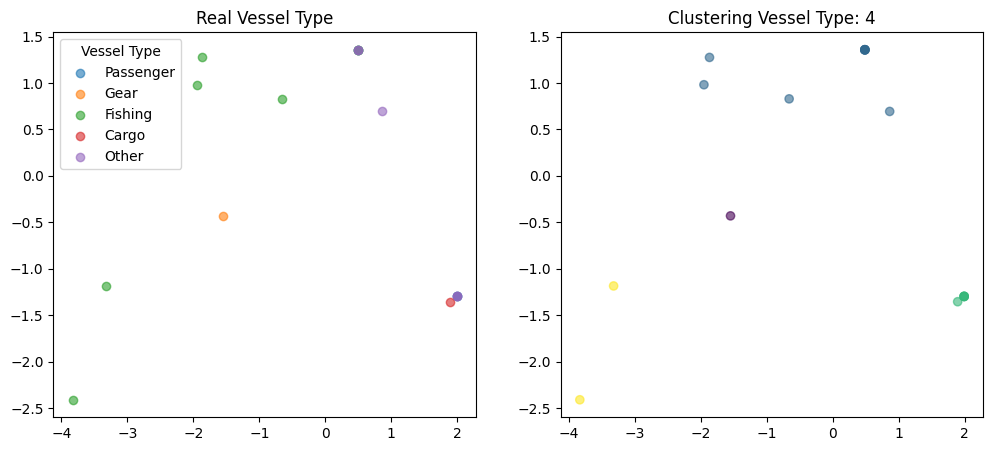

In [126]:
n_clusters=4
X = generate_feature(vessels, vessel_event_feature_engineering_2)
y_pred = clustering(X, n_clusters=n_clusters)

metrics(X, y_pred)
pca2d_plot(X, y, y_pred, n_clusters)


Silhouette Score: 0.7369653245030044
Davies-Bouldin Score 0.3081760159326564


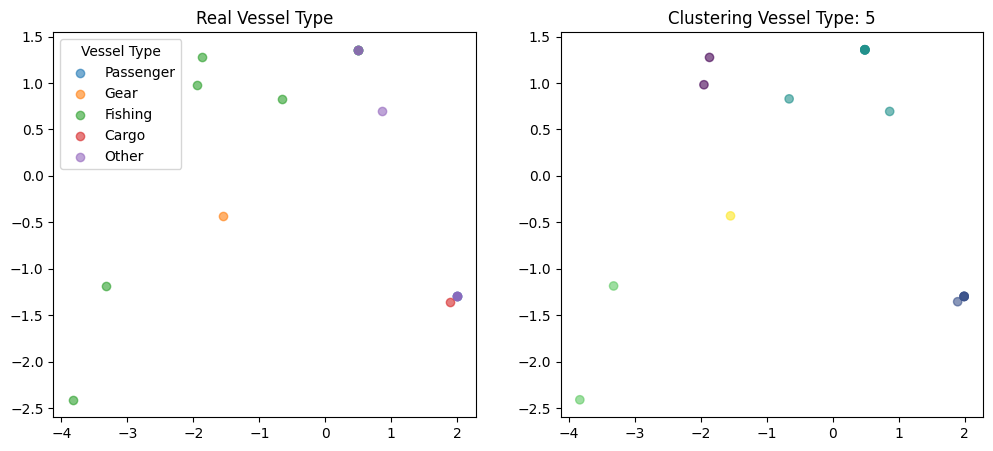

In [127]:
n_clusters=5
X = generate_feature(vessels, vessel_event_feature_engineering_2)
y_pred = clustering(X, n_clusters=n_clusters)

metrics(X, y_pred)
pca2d_plot(X, y, y_pred, n_clusters)

In [145]:
flag_type = [vessel_info(vessel) for vessel in vessels]
y = []
for fv, ft in flag_type:
    if type(fv) == float:
        fv = "UnKwn"
    y.append(fv + '-' + ft)


Silhouette Score: 0.7369653245030044
Davies-Bouldin Score 0.3081760159326564


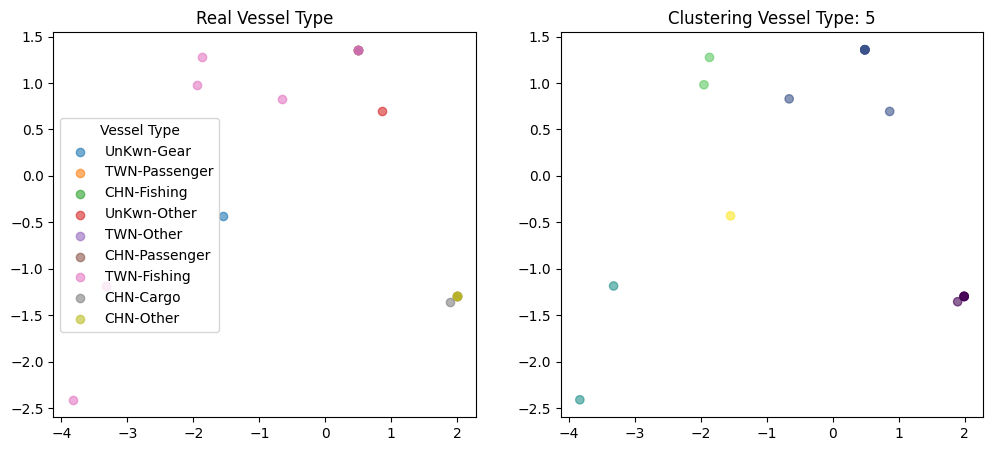

In [146]:
n_clusters=5
X = generate_feature(vessels, vessel_event_feature_engineering_2)
y_pred = clustering(X, n_clusters=n_clusters)

metrics(X, y_pred)
pca2d_plot(X, y, y_pred, n_clusters)


Silhouette Score: 0.6630757138781896
Davies-Bouldin Score 0.15693500238815464


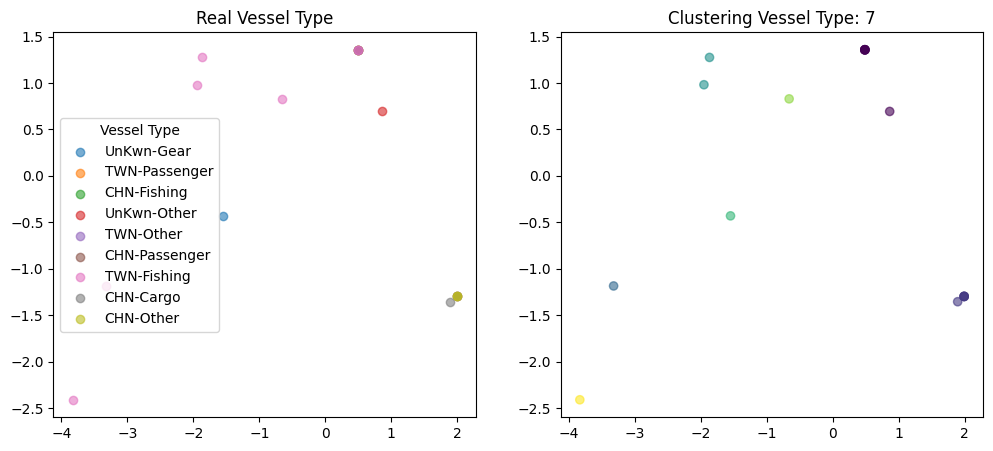


Silhouette Score: 0.6630757138781896
Davies-Bouldin Score 0.15693500238815464


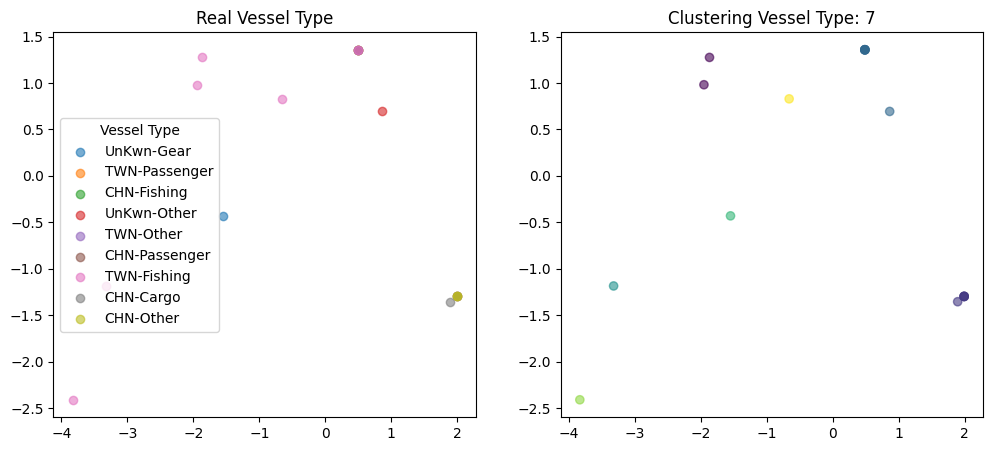

In [148]:
n_clusters=7
X = generate_feature(vessels, vessel_event_feature_engineering_2)
y_pred = clustering(X, n_clusters=n_clusters)

metrics(X, y_pred)
pca2d_plot(X, y, y_pred, n_clusters)


Silhouette Score: 0.5777579090634524
Davies-Bouldin Score 0.01797325100788444


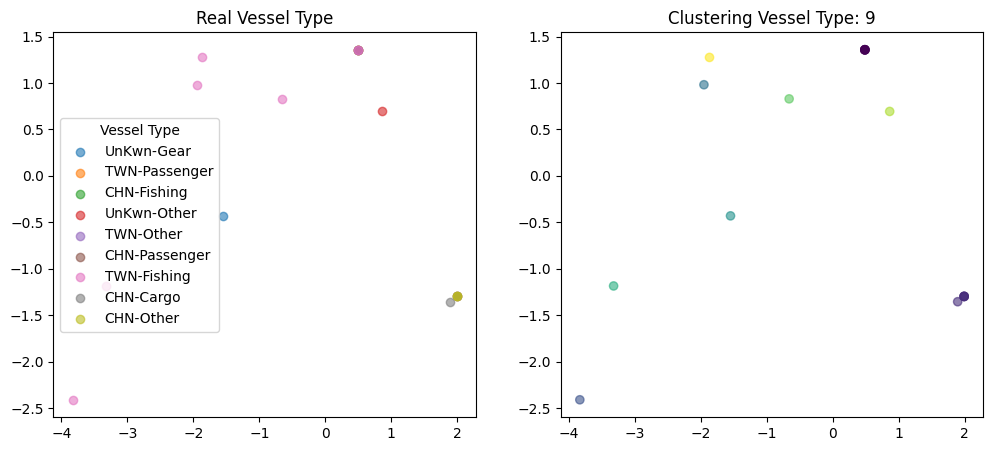

In [149]:
n_clusters=9
X = generate_feature(vessels, vessel_event_feature_engineering_2)
y_pred = clustering(X, n_clusters=n_clusters)

metrics(X, y_pred)
pca2d_plot(X, y, y_pred, n_clusters)

## Cateogry 3: Temporal Features

In [167]:
all_events = df[(df["label"] == "type") & (df["node2"] == "Event")].node1.values
zero_event = []
non_zero_event = []

for event in all_events:
    vdf = df[df["node1"] == event]
    start = vdf[vdf["label"] == "StartTime"].node2.values[0]
    end = vdf[vdf["label"] == "EndTime"].node2.values[0]

    if start == end:
        zero_event.append(event)
    else:
        non_zero_event.append(evnet)

print(f"Zero Event: {len(zero_event)}")
print(f"Non Zero Event: {len(non_zero_event)}")

Zero Event: 1698
Non Zero Event: 0


## Category Event Transfer

In [175]:
EVENT_TYPES = ["PortVisitEvent", "LoiteringEvent", "FishingEvent"]
ZONES = ["Zone_204", "Zone_196", "Zone_222", "Zone_207"]
ZONE_CATEGORY = {zone:idx for idx, zone in enumerate(ZONES)}

def vessel_event_feature_engineering_4(vessel: str) -> List:
    # Event Ratios(3), MeanEvent Duration(3), temporal behavior(3), spatial behavior(3)
    def count_event(vessel: str):
        counter = {event_type:0 for event_type in EVENT_TYPES}
        
        events = df[(df["label"] == "HasParticipant") &
                    (df["node2"] == vessel)].node1.values
        events = list(map(lambda x: x.split('_')[0], events))
        for event in events:
            counter[event] += 1
        
        return counter

    def count_zone(vessel: str) -> List:
        counter = {zone:0 for zone in ZONES}
        events = df[(df["label"] == "HasParticipant") &
                    (df["node2"] == vessel)].node1.values

        for event in events:
            zone = df[(df["node1"] == event) &
                      (df["label"] == "Location")].node2.values[0]
            counter[zone] += 1

        return counter

    def count_event_transfer(vessel: str) -> List:
        counter = {}
        for et0 in EVENT_TYPES:
            for et1 in EVENT_TYPES:
                if et0 != et1:
                    counter[et0 + '-' + et1] = 0

        events = df[(df["label"] == "HasParticipant") &
                    (df["node2"] == vessel)].node1.values
        events = list(map(lambda x: x.split('_')[0], events))

        for i in range(len(events) - 1):
            if events[i] != events[i + 1]:
                counter[events[i] + '-' + events[i + 1]] += 1

        return counter

    event_counter = count_event(vessel)
    zone_counter = count_zone(vessel)
    event_transfer_counter = count_event_transfer(vessel)
    n_event = sum(event_counter.values())

    # count value return
    return \
        list(event_counter.values()) + \
        list(zone_counter.values()) + \
        list(event_transfer_counter.values())


Silhouette Score: 0.4968844850691351
Davies-Bouldin Score 0.21859905085724146


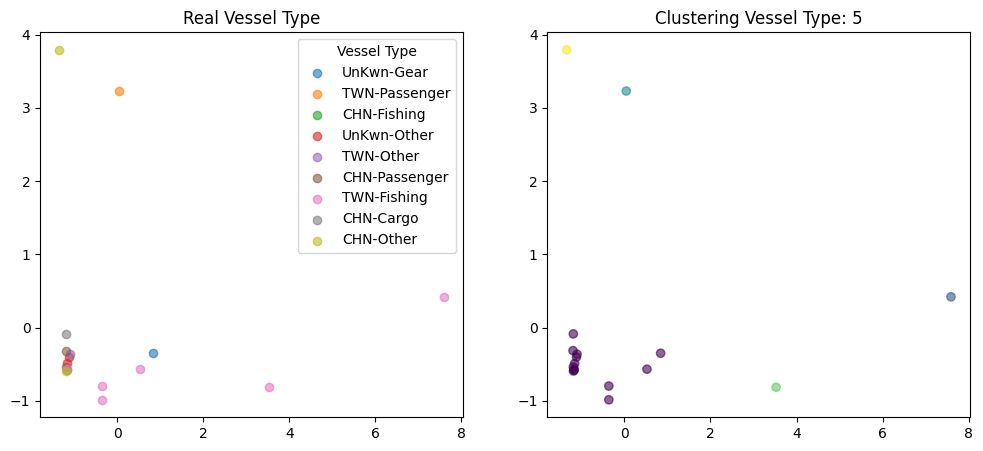

In [176]:
n_clusters = 5
X = generate_feature(vessels, vessel_event_feature_engineering_4)
y_pred = clustering(X, n_clusters=n_clusters)

metrics(X, y_pred)
pca2d_plot(X, y, y_pred, n_clusters)


Silhouette Score: 0.5629294987910187
Davies-Bouldin Score 0.21087470771538896


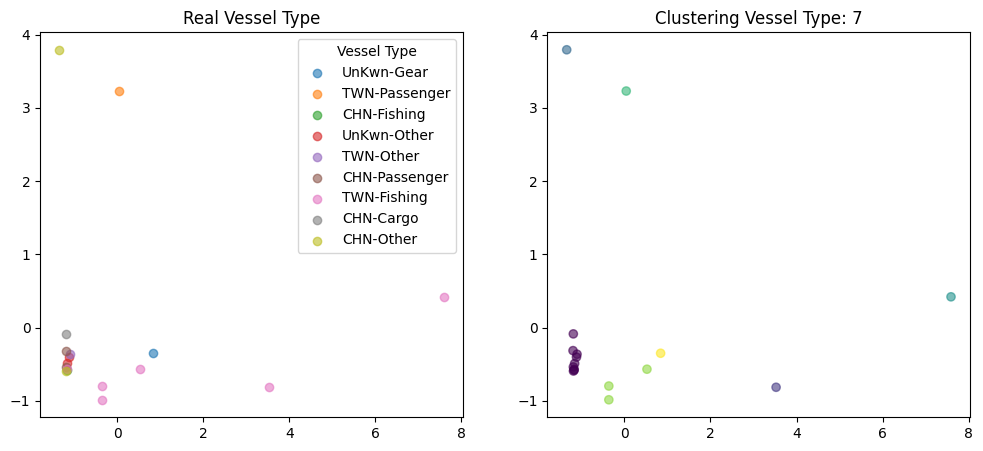

In [177]:
n_clusters = 7
X = generate_feature(vessels, vessel_event_feature_engineering_4)
y_pred = clustering(X, n_clusters=n_clusters)

metrics(X, y_pred)
pca2d_plot(X, y, y_pred, n_clusters)


Silhouette Score: 0.39865571606340733
Davies-Bouldin Score 0.17302392869666763


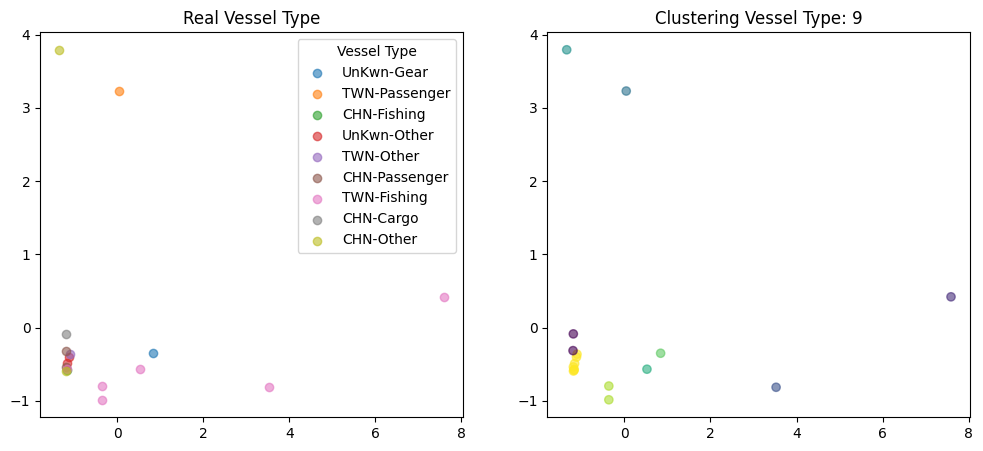

In [178]:
n_clusters = 9
X = generate_feature(vessels, vessel_event_feature_engineering_4)
y_pred = clustering(X, n_clusters=n_clusters)

metrics(X, y_pred)
pca2d_plot(X, y, y_pred, n_clusters)